In [136]:
%run general_functions.ipynb

In [137]:
def horizontal_weights(data, var, mask, mask_var, oper):

    weights = mask[mask_var].fillna(0)
    if oper == 'ave':
        data_weighted = data.weighted(weights).mean(('x','y'))
    elif oper == 'sum':
        data_weighted = data.weighted(weights).sum(('x','y'))
    
    return data_weighted

In [138]:
def lin_regr(data, var):
    
    t = np.arange(len(data.time_counter))
    y = data[var]
    slope, intercept, r_value, p_value, std_err = linregress(t, y)
    y_pred = intercept + slope * t
    
    return y_pred

In [139]:
def fig_plot_map(data, var, ax, vmin, vmax, oae_index, base_index):
    # get the difference between oae and baseline over time, then compute the 10-year mean
    if var != 'DIC':
        da = ((list(data.values())[oae_index]-list(data.values())[base_index]).mean('year'))[var]
    else:
        da = (list(data.values())[oae_index].isel(year=-1)-list(data.values())[base_index].isel(year=-1))[var]

    lon, lat = da['nav_lon'].mean('y'), da['nav_lat'].mean('x')
    im = ax.pcolormesh(lon, lat,
        da,
        cmap=cmap,
        vmin=vmin,vmax=vmax,)

    return im

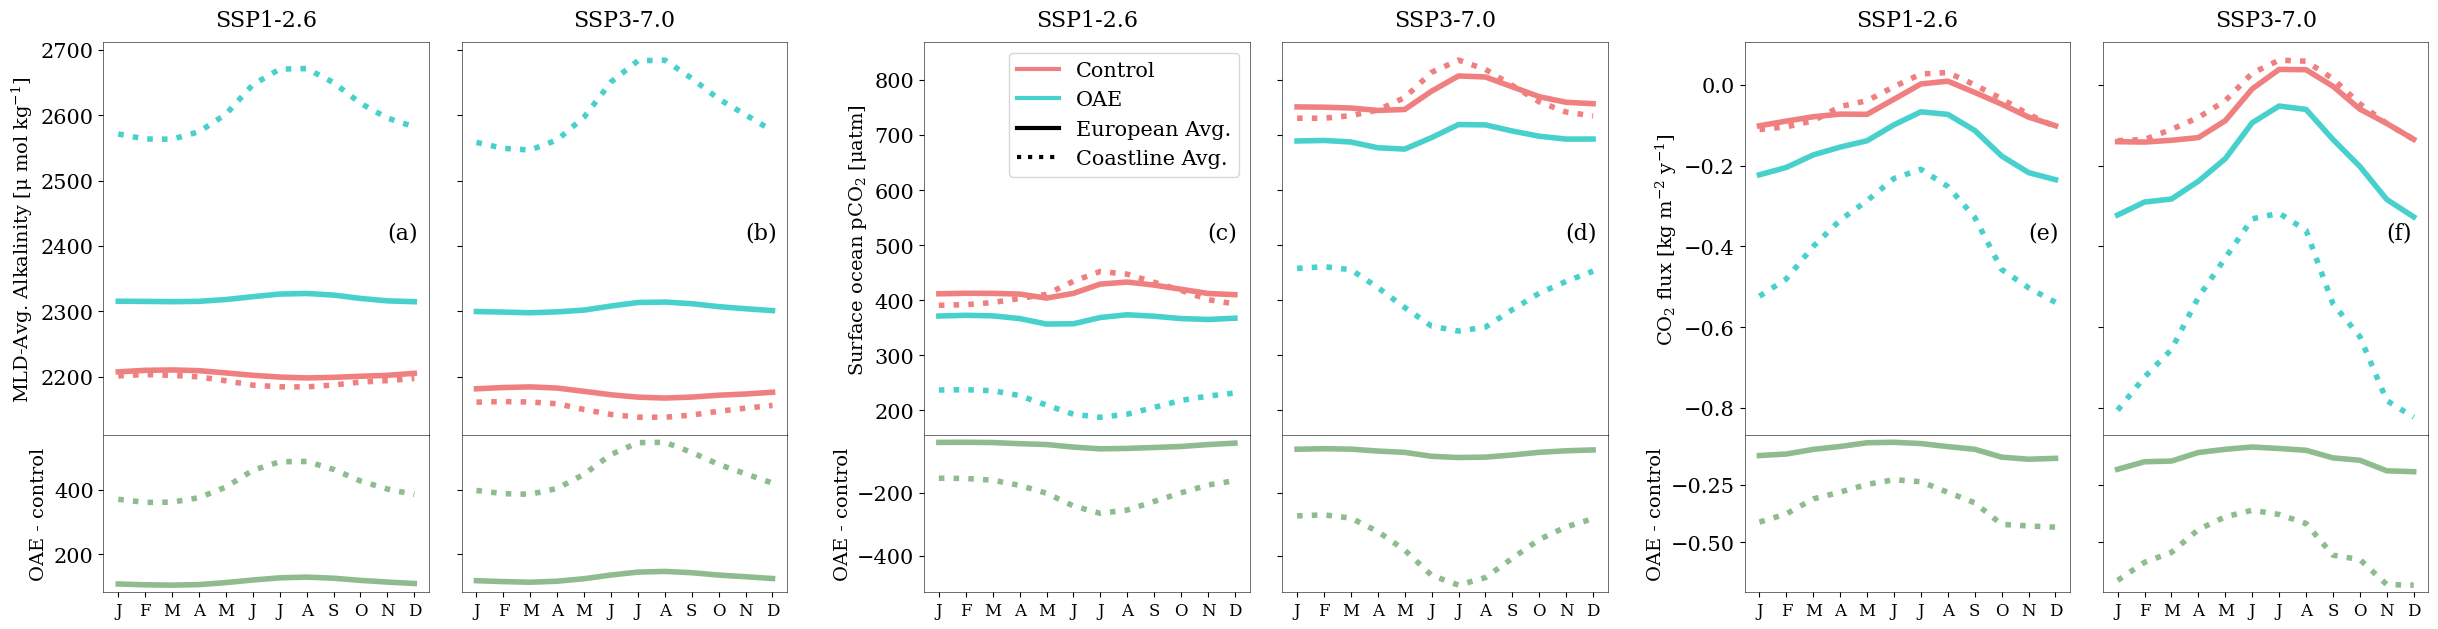

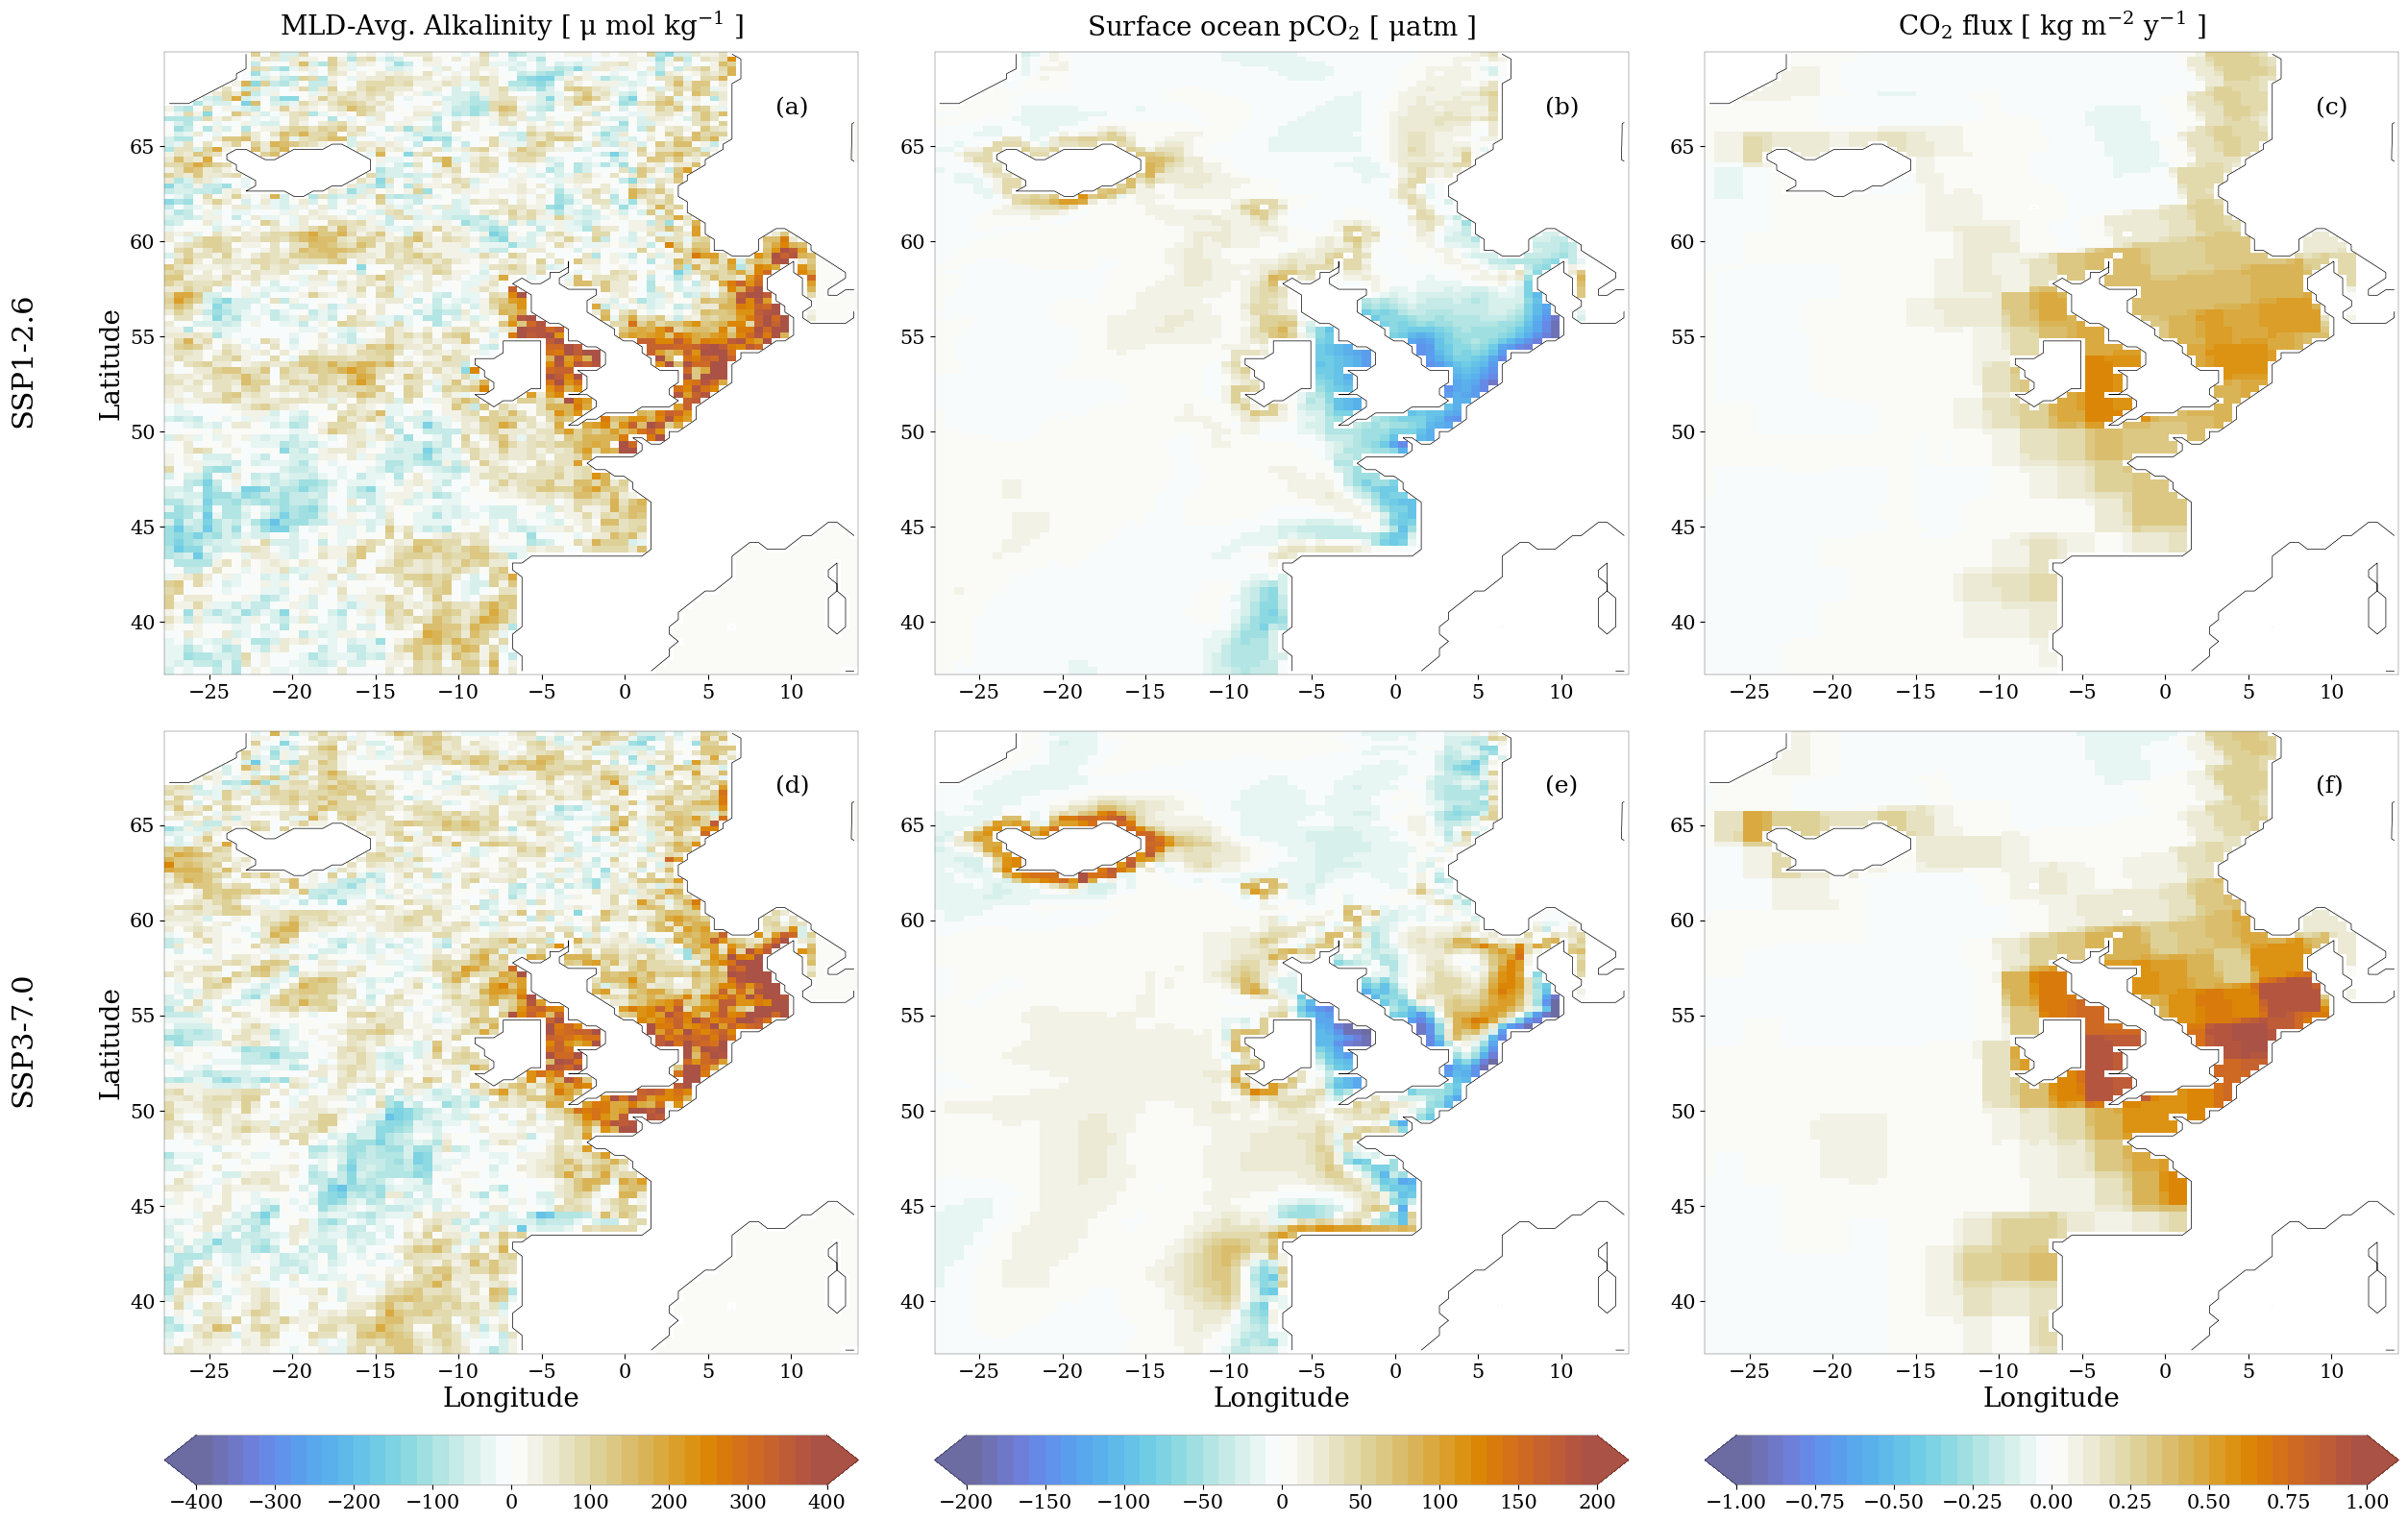

In [159]:
# -----------------------------
figures = ['lineplot','map']
# -----------------------------

# variable names
vars = {
            'ALK':     {'var_name': 'ALK',      'long': 'MLD-Avg. Alkalinity',                                           'unit': r'μ mol $\mathregular{kg^{-1}}$',     'value':400},
            'fco2':    {'var_name': 'fco2',     'long': 'Surface ocean p$\mathregular{CO_{2}}$',                         'unit': r'μatm',                              'value':200},
            'co2flux': {'var_name': 'co2flux',  'long': '$\mathregular{CO_{2}}$ flux',           'conv_term':'31536000', 'unit': r'kg $\mathregular{m^{-2} \ y^{-1}}$', 'value':1},
}

mlds = {     
            'mld':     {'var_name': 'somxl010', 'long': 'Mixed Layer Depth',                                             'unit': r'm'}
}

for fig in figures:

    scenarios = {'126' : 'SSP1-2.6', '370': 'SSP3-7.0'}
    runs = {'baseline' : 'Control', 'oae' : 'OAE'}
    
    mesh_mask = xr.open_dataset(data_path+'mesh_mask.nc').isel(z=0,t=0)
    polygon_boundaries = polygon_mask(mesh_mask)
    mesh = mesh_mask['tmask'] * polygon_boundaries
           
    ocn_mask = ocean_mask(data_path, var)
    cst_mask = coastline_mask(data_path + '../alk_mask/', var)
    
    def seasonal_analysis(file_path, mask, mask_var, location):
        mld_datasets = {}
        for scen, scen_key in scenarios.items():
            mld_datasets[scen] = {}
            for mld, mld_keys in mlds.items():
                mld_datasets[scen][mld] = {}
                for run, run_key in runs.items():
                    mld_datasets[scen][mld][run] = data_path + mld + f'_{run}_{scen}.nc'
    
        file_path = {}
        amplitude_line = {}
        amplitude_map = {}
        
        for scen, scen_key in scenarios.items():
            
            file_path[scen] = {}
            amplitude_line[scen] = {}
            amplitude_map[scen] = {}
           
            for var, var_name in vars.items():
                file_path[scen][var] = {}
                amplitude_line[scen][var] = {}
                amplitude_map[scen][var] = {}
                
                for run, run_key in runs.items():
                    data = xr.open_dataset(data_path + var + f'_{run}_{scen}.nc')
                    data_mld = xr.open_dataset(mld_datasets[scen][mld][run])
                    
                    if var in ['sosstsst','bgc_diag_pp']:
                        mesh_sliced = mesh.sel(x=slice(519, 595), y=slice(329, 435))
                    else:
                        mesh_sliced = mesh.sel(x=slice(520, 595), y=slice(330, 435))
                    conv_term = eval(vars[var].get('conv_term')) if 'conv_term' in vars[var].keys() else 1
        
                    mesh_sliced = mesh_sliced.where(mesh_sliced)
                    data = data * mesh_sliced * conv_term
    
                    if var in ['ALK','DIC']:
                        if fig == 'lineplot':
                            data = data.isel(deptht=0)
        
                        elif fig == 'map':
                            data[var] = data[var].where(data['deptht'] < data_mld['somxl010'])
                            data = vertical_weights(data, var, data_mld, 'somxl010', 'ave')
                
                    data_line = horizontal_weights(data, var, mask, mask_var, 'ave')
                    data_line = seasonal_avg(data_line, var)
                    amplitude_line[scen][var][run] = data_line
    
                    data_map = ((data.groupby('time_counter.year').max(dim='time_counter'))-(data.groupby('time_counter.year').min(dim='time_counter'))).mean('year')
                    amplitude_map[scen][var][run] = data_map
                    
                control, oae = runs.keys()
                amplitude_line[scen][var]['delta'] = amplitude_line[scen][var][oae] - amplitude_line[scen][var][control]
                amplitude_map[scen][var]['delta'] = amplitude_map[scen][var][oae] - amplitude_map[scen][var][control]
    
        return amplitude_line, amplitude_line, amplitude_line, amplitude_map
        
    control_europe, oae_europe, amplitude_line_europe, amplitude_map_europe = seasonal_analysis(file_path, ocn_mask, 'tmask', 'europe')
    control_coast, oae_coast, amplitude_line_coast, amplitude_map_coast = seasonal_analysis(file_path, cst_mask, 'alk_flux', 'coastline')
    
    # LINEPLOT
    
    if fig == 'lineplot':
        fig = plt.figure(figsize=(30, 50))
        gs0 = gridspec.GridSpec(6, 3, hspace=0.2)
        
        s_126, s_370 = scenarios.keys()
        r_control, r_oae = runs.keys()
        
        colors = {'control': 'lightcoral', 'oae': 'mediumturquoise'}
        delta_color = 'darkseagreen'
        lw = 4
        
        axes = []
        
        def plot_main(ax, scen, var):
            ax.plot(control_europe[scen][var][r_control][var],
                    color=colors['control'], lw=lw)
            ax.plot(oae_europe[scen][var][r_oae][var],
                    color=colors['oae'], lw=lw)
        
            ax.plot(control_coast[scen][var][r_control][var],
                    color=colors['control'], ls=':', lw=lw)
            ax.plot(oae_coast[scen][var][r_oae][var],
                    color=colors['oae'], ls=':', lw=lw)
        
        
        def plot_delta(ax, scen, var):
            ax.plot(amplitude_line_europe[scen][var]['delta'][var],
                    color=delta_color, lw=lw)
            ax.plot(amplitude_line_coast[scen][var]['delta'][var],
                    color=delta_color, ls=':', lw=lw)
        
        
        for row, (var, keys) in enumerate(vars.items()):
            long = keys['long']
            unit = keys['unit']
        
            gs = gridspec.GridSpecFromSubplotSpec(
                2, 2,
                subplot_spec=gs0[row],
                height_ratios=[1, 0.4],
                width_ratios=[1, 1],
                hspace=0,
                wspace=0.1
            )
        
            row_axes = []
        
            for col, scen in enumerate(scens):
                ax_top = fig.add_subplot(gs[0, col])
                ax_bot = fig.add_subplot(gs[1, col], sharex=ax_top)
        
                if col == 1:
                    ax_top.sharey(row_axes[0])
                    ax_bot.sharey(row_axes[1])
                    ax_top.tick_params(labelleft=False)
                    ax_bot.tick_params(labelleft=False)
        
                plot_main(ax_top, scen, var)
                plot_delta(ax_bot, scen, var)
        
                ax_top.set_title(list(scenarios.values())[col], fontsize=16, y=1.02)
        
                row_axes.extend([ax_top, ax_bot])
        
            row_axes[0].set_ylabel(f"{long} [{unit}]", fontsize=14)
            row_axes[1].set_ylabel("OAE - control", fontsize=14)
        
            axes.extend(row_axes)
        
        # Styling
        for ax in axes:
            month_x_labels(ax)
            ax.tick_params(axis='both', which='major')
            fineline(ax, 0.4)
        
        # Legend once
        legend_handles = [
            Line2D([0], [0], color=colors['control'], lw=3, label='Control'),
            Line2D([0], [0], color=colors['oae'], lw=3, label='OAE'),
            Line2D([0], [0], color='black', lw=3, label='European Avg.'),
            Line2D([0], [0], color='black', lw=3, ls=':', label='Coastline Avg.')
        ]
        
        axes[4].legend(handles=legend_handles, loc='best')
        
        # Panel labels
        for n, ax in enumerate(axes[::2]):
            ax.text(
                0.87, 0.5,
                f"({string.ascii_lowercase[n]})",
                transform=ax.transAxes,fontsize=16
            )
    
        plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/figure3.png')
    
    
    # MAP
    
    elif fig == 'map':
        
        fig, axes = plt.subplots(2,3, figsize=(30, 22))
        plt.subplots_adjust(wspace=0.11, hspace=0.09)
        plt.rcParams['axes.linewidth'] = .2
        
        cmap, norm = create_discrete_cmap(cm.prinsenvlag_r, 40)
        
        d = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/datasets/last_decade/ALK_baseline_126.nc')
        lon, lat = d['nav_lon'].mean('y'), d['nav_lat'].mean('x')
        
        for row, scen in enumerate(scenarios.keys()):
                    
            for col, (var, keys) in enumerate(vars.items()):
                v = keys['value']
                ax = axes[row][col]   # 2D structure preferred
        
                im = ax.pcolormesh(
                    lon,
                    lat,
                    amplitude_map_europe[scen][var]['delta'][var],
                    cmap=cmap,
                    vmin=-v, vmax=v
                )
        
                ax.set_title(
                    f"{vars[var]['long']} [ {vars[var]['unit']} ]",
                    pad=12
                )
                if row == 1:
                    ax.set_title('')
                    ax.set_xlabel('Longitude')

                    fig.colorbar(
                        im,
                        ax=axes[:,col],
                        orientation='horizontal',
                        pad=0.05,
                        extend='both',
                        aspect=14
                    )
                    
                if col == 0 :
                    ax.set_ylabel('Latitude')
                    ax.text(-37,50.5, f'{list(scenarios.values())[row]}', rotation=90, fontsize=22)
            
        axes = axes.flatten()
        for ax in axes:
            ax.contour(lon, lat, d['ALK'].isel(deptht=0,time_counter=0), levels=[3], colors='black', linewidths=.5)
               
        for n, ax in enumerate(axes):
            ax.text(0.88, 0.9, f'({string.ascii_lowercase[n]})',
                    transform=ax.transAxes, color='black', fontsize=18)
        
        pass
        
        plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/figure5.png')